# 03. Extracción de características visuales y embeddings — versión optimizada

Este notebook corresponde al **paso 03** del pipeline.

Toma como base lo generado en el **paso 02: detección del perro y clasificación de raza**.  
La idea es generar dos tipos de representaciones para cada imagen válida:

1. **Características visuales interpretables**, calculadas con OpenCV.
2. **Embeddings profundos**, extraídos desde el modelo EfficientNet entrenado en el paso 02.


## Objetivo del paso 03

El objetivo es transformar imágenes en datos analizables:

| Tipo de salida | Qué representa | Para qué sirve |
|---|---|---|
| Features visuales | Brillo, contraste, nitidez, color, tamaño relativo | Interpretar calidad visual y condiciones de imagen |
| Embeddings profundos | Vector numérico aprendido por EfficientNet | Comparar imágenes, buscar similitud visual y preparar el paso 04 |

La diferencia clave es que las features manuales son explicables directamente, mientras que los embeddings capturan patrones visuales complejos aprendidos por el modelo.

In [1]:
# 0. Instalación de dependencias

!pip install -q tensorflow opencv-python pillow scikit-learn pandas matplotlib tqdm

In [2]:
# 1. Imports y configuración general

from pathlib import Path
import os
import json
import math
import time
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [3]:
# 2. Montar Google Drive

from google.colab import drive

if Path("/content/drive/MyDrive").exists():
    print("Google Drive ya está montado.")
else:
    drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
# 3. Rutas del proyecto

PROJECT_PATH = Path("/content/drive/MyDrive/proyecto_integrador")

DATA_PROCESSED_PATH = PROJECT_PATH / "data_processed"

STEP02_PATH = DATA_PROCESSED_PATH / "step02_detection_classification"
STEP02_REPORTS_PATH = STEP02_PATH / "reports"
STEP02_CROPS_PATH = STEP02_PATH / "dog_crops_from_curated_v2"

MODELS_PATH = PROJECT_PATH / "models"

# Salidas del paso 03
STEP03_PATH = DATA_PROCESSED_PATH / "step03_visual_features_embeddings"
STEP03_REPORTS_PATH = STEP03_PATH / "reports"
STEP03_ARRAYS_PATH = STEP03_PATH / "arrays"
STEP03_PLOTS_PATH = STEP03_PATH / "plots"

for p in [STEP03_PATH, STEP03_REPORTS_PATH, STEP03_ARRAYS_PATH, STEP03_PLOTS_PATH]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_PATH:", PROJECT_PATH)
print("STEP02_REPORTS_PATH:", STEP02_REPORTS_PATH)
print("MODELS_PATH:", MODELS_PATH)
print("STEP03_PATH:", STEP03_PATH)

PROJECT_PATH: /content/drive/MyDrive/proyecto_integrador
STEP02_REPORTS_PATH: /content/drive/MyDrive/proyecto_integrador/data_processed/step02_detection_classification/reports
MODELS_PATH: /content/drive/MyDrive/proyecto_integrador/models
STEP03_PATH: /content/drive/MyDrive/proyecto_integrador/data_processed/step03_visual_features_embeddings


## Selección de variante de entrada

Este paso debe usar la misma variante ganadora del paso 02.

| Variante | Qué usa |
|---|---|
| `yolo_crop` | Recorte del perro detectado por YOLO |
| `full_curated_image` | Imagen completa curada V2 |

Si todavía no comparaste ambas, usa `yolo_crop` porque es el flujo principal del pipeline.

In [5]:
# 4. Configuración del experimento


INPUT_VARIANT = "yolo_crop"
# INPUT_VARIANT = "full_curated_image"

IMG_SIZE = 224
BATCH_SIZE_EMBEDDINGS = 64

# Modelo entrenado en el paso 02.
PREFERRED_MODEL_PATH = MODELS_PATH / f"step02_{INPUT_VARIANT}_efficientnetb0_best.keras"

# Reporte principal de detección del paso 02.
DETECTION_REPORT_PATH = STEP02_REPORTS_PATH / "step02_yolo_detection_report.csv"

print("INPUT_VARIANT:", INPUT_VARIANT)
print("PREFERRED_MODEL_PATH:", PREFERRED_MODEL_PATH)
print("DETECTION_REPORT_PATH:", DETECTION_REPORT_PATH)

INPUT_VARIANT: yolo_crop
PREFERRED_MODEL_PATH: /content/drive/MyDrive/proyecto_integrador/models/step02_yolo_crop_efficientnetb0_best.keras
DETECTION_REPORT_PATH: /content/drive/MyDrive/proyecto_integrador/data_processed/step02_detection_classification/reports/step02_yolo_detection_report.csv


In [6]:
# 5. Cargar reporte del paso 02

if not DETECTION_REPORT_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el reporte de detección del paso 02: {DETECTION_REPORT_PATH}\n"
        "Primero ejecuta el notebook 02 y verifica que exista step02_yolo_detection_report.csv"
    )

step02_df = pd.read_csv(DETECTION_REPORT_PATH)

print("Registros cargados del paso 02:", len(step02_df))
print("Columnas disponibles:")
print(step02_df.columns.tolist())

display(step02_df.head())

Registros cargados del paso 02: 20580
Columnas disponibles:
['image_path', 'image_name', 'breed', 'breed_folder', 'selected_yolo_model', 'dog_detected', 'num_detections', 'best_confidence', 'best_area', 'crop_path', 'status', 'error']


,image_path,image_name,breed,breed_folder,selected_yolo_model,dog_detected,num_detections,best_confidence,best_area,crop_path,status,error
0,/content/drive/MyDrive/proyecto_integrador/ima...,n02085620_10074.jpg,Chihuahua,n02085620-Chihuahua,yolo26s.pt,True,1,0.909835,23328.0,/content/drive/MyDrive/proyecto_integrador/dat...,detected_and_cropped,NaN
1,/content/drive/MyDrive/proyecto_integrador/ima...,n02085620_10131.jpg,Chihuahua,n02085620-Chihuahua,yolo26s.pt,True,1,0.807467,34226.0,/content/drive/MyDrive/proyecto_integrador/dat...,detected_and_cropped,NaN
2,/content/drive/MyDrive/proyecto_integrador/ima...,n02085620_10621.jpg,Chihuahua,n02085620-Chihuahua,yolo26s.pt,True,1,0.950614,7735.0,/content/drive/MyDrive/proyecto_integrador/dat...,detected_and_cropped,NaN
3,/content/drive/MyDrive/proyecto_integrador/ima...,n02085620_1073.jpg,Chihuahua,n02085620-Chihuahua,yolo26s.pt,True,1,0.805748,29329.0,/content/drive/MyDrive/proyecto_integrador/dat...,detected_and_cropped,NaN
4,/content/drive/MyDrive/proyecto_integrador/ima...,n02085620_10976.jpg,Chihuahua,n02085620-Chihuahua,yolo26s.pt,True,1,0.948959,11520.0,/content/drive/MyDrive/proyecto_integrador/dat...,detected_and_cropped,NaN


In [7]:
# 6. Seleccionar imágenes válidas para el paso 03

required_base_cols = ["image_path", "breed", "dog_detected", "crop_path"]
missing_cols = [c for c in required_base_cols if c not in step02_df.columns]

if missing_cols:
    raise ValueError(
        f"Faltan columnas necesarias en el reporte del paso 02: {missing_cols}. "
        "Verifica que el paso 02 haya generado image_path, breed, dog_detected y crop_path."
    )

valid_df = step02_df[
    (step02_df["dog_detected"] == True) &
    (step02_df["crop_path"].notna())
].copy()

# Selección de entrada visual para features/embeddings
if INPUT_VARIANT == "yolo_crop":
    valid_df["image_input_path"] = valid_df["crop_path"]
elif INPUT_VARIANT == "full_curated_image":
    valid_df["image_input_path"] = valid_df["image_path"]
else:
    raise ValueError("INPUT_VARIANT debe ser 'yolo_crop' o 'full_curated_image'.")

# Validar existencia de archivos
valid_df["image_exists"] = valid_df["image_input_path"].apply(lambda x: Path(str(x)).exists())
missing_files = int((~valid_df["image_exists"]).sum())

print("Imágenes válidas con perro detectado:", len(valid_df))
print("Archivos no encontrados:", missing_files)

if missing_files > 0:
    print("Ejemplos de archivos no encontrados:")
    display(valid_df[~valid_df["image_exists"]].head())

valid_df = valid_df[valid_df["image_exists"]].reset_index(drop=True)

print("Imágenes disponibles para paso 03:", len(valid_df))
display(valid_df[["image_input_path", "breed", "best_confidence", "best_area"]].head())

Imágenes válidas con perro detectado: 18807
Archivos no encontrados: 0
Imágenes disponibles para paso 03: 18807


,image_input_path,breed,best_confidence,best_area
0,/content/drive/MyDrive/proyecto_integrador/dat...,Chihuahua,0.909835,23328.0
1,/content/drive/MyDrive/proyecto_integrador/dat...,Chihuahua,0.807467,34226.0
2,/content/drive/MyDrive/proyecto_integrador/dat...,Chihuahua,0.950614,7735.0
3,/content/drive/MyDrive/proyecto_integrador/dat...,Chihuahua,0.805748,29329.0
4,/content/drive/MyDrive/proyecto_integrador/dat...,Chihuahua,0.948959,11520.0


## Optimización de lectura de imágenes

Para mejorar el rendimiento, esta sección copia las imágenes necesarias a `/content`, que es el almacenamiento local temporal de Colab. Después actualiza `valid_df["image_input_path"]` para que el resto del notebook lea desde disco local.

Esta mejora no modifica las imágenes ni sus etiquetas; únicamente cambia la ruta desde donde se leen.


In [8]:
# 6B. Optimización de lectura: copiar imágenes a /content

from pathlib import Path
import subprocess
import shutil
import time

USE_LOCAL_CONTENT_STORAGE = True

if USE_LOCAL_CONTENT_STORAGE:
    if INPUT_VARIANT == "yolo_crop":
        DRIVE_BASE_PATH = Path("/content/drive/MyDrive/proyecto_integrador/data_processed/step02_detection_classification/dog_crops_from_curated_v2")
        LOCAL_BASE_PATH = Path("/content/dog_crops_from_curated_v2")

    elif INPUT_VARIANT == "full_curated_image":
        DRIVE_BASE_PATH = Path("/content/drive/MyDrive/proyecto_integrador/images_curated_rgb_v2")
        LOCAL_BASE_PATH = Path("/content/images_curated_rgb_v2")

    else:
        raise ValueError("INPUT_VARIANT debe ser 'yolo_crop' o 'full_curated_image'.")

    print("Ruta original en Drive:", DRIVE_BASE_PATH)
    print("Ruta local en Colab:", LOCAL_BASE_PATH)

    if not DRIVE_BASE_PATH.exists():
        raise FileNotFoundError(f"No existe la ruta fuente en Drive: {DRIVE_BASE_PATH}")

    start_copy = time.time()

    if not LOCAL_BASE_PATH.exists():
        LOCAL_BASE_PATH.parent.mkdir(parents=True, exist_ok=True)

        print("Copiando imágenes a /content. Esto puede tardar unos minutos...")
        subprocess.run(
            ["cp", "-r", str(DRIVE_BASE_PATH), str(LOCAL_BASE_PATH)],
            check=True
        )
    else:
        print("La carpeta local ya existe. No se vuelve a copiar.")

    elapsed_copy = (time.time() - start_copy) / 60
    print("Tiempo de copia:", round(elapsed_copy, 2), "minutos")

    # Guardar ruta original para trazabilidad
    valid_df["original_image_input_path"] = valid_df["image_input_path"]

    # Reemplazar ruta de Drive por ruta local
    valid_df["image_input_path"] = valid_df["image_input_path"].astype(str).str.replace(
        str(DRIVE_BASE_PATH),
        str(LOCAL_BASE_PATH),
        regex=False
    )

    # Validar existencia de archivos locales
    valid_df["image_exists_local"] = valid_df["image_input_path"].apply(lambda p: Path(p).exists())

    print("Validación de archivos locales:")
    print(valid_df["image_exists_local"].value_counts(dropna=False))

    missing_local = valid_df[~valid_df["image_exists_local"]].copy()

    if len(missing_local) > 0:
        print("Advertencia: hay archivos que no existen localmente. Ejemplos:")
        display(missing_local[["original_image_input_path", "image_input_path"]].head())

    valid_df = (
        valid_df[valid_df["image_exists_local"]]
        .drop(columns=["image_exists_local"])
        .reset_index(drop=True)
    )

    print("Imágenes disponibles para extracción de features:", len(valid_df))
    display(valid_df[["image_input_path", "breed"]].head())

else:
    print("USE_LOCAL_CONTENT_STORAGE=False. Se leerán imágenes desde la ruta original.")


Ruta original en Drive: /content/drive/MyDrive/proyecto_integrador/data_processed/step02_detection_classification/dog_crops_from_curated_v2
Ruta local en Colab: /content/dog_crops_from_curated_v2
Copiando imágenes a /content. Esto puede tardar unos minutos...
Tiempo de copia: 14.78 minutos
Validación de archivos locales:
image_exists_local
True    18807
Name: count, dtype: int64
Imágenes disponibles para extracción de features: 18807


,image_input_path,breed
0,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua
1,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua
2,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua
3,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua
4,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua


# Extracción de características visuales interpretables

En esta primera parte se calculan variables visuales con OpenCV.  
Estas variables permiten describir la imagen de manera interpretable.

Ejemplos:

- Brillo promedio.
- Contraste.
- Nitidez.
- Saturación.
- Color dominante.
- Densidad de bordes.
- Tamaño relativo del perro, cuando exista información de detección.

Estas variables no sustituyen al embedding profundo; lo complementan.

In [9]:
# 7. Funciones para extracción de features visuales

def safe_read_image_bgr(img_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    return img


def compute_brightness_contrast(gray):
    brightness = float(np.mean(gray))
    contrast = float(np.std(gray))
    return brightness, contrast


def compute_sharpness(gray):
    # Varianza del Laplaciano: mayor valor suele indicar mayor nitidez.
    return float(cv2.Laplacian(gray, cv2.CV_64F).var())


def compute_edge_density(gray):
    edges = cv2.Canny(gray, 100, 200)
    return float(np.mean(edges > 0))


def compute_colorfulness(img_bgr):
    # Métrica de colorfulness basada en diferencias entre canales.
    b, g, r = cv2.split(img_bgr.astype("float"))
    rg = np.abs(r - g)
    yb = np.abs(0.5 * (r + g) - b)

    std_rg, mean_rg = np.std(rg), np.mean(rg)
    std_yb, mean_yb = np.std(yb), np.mean(yb)

    return float(np.sqrt(std_rg**2 + std_yb**2) + 0.3 * np.sqrt(mean_rg**2 + mean_yb**2))


def compute_dominant_color_simple(img_bgr):
    # Promedio RGB como aproximación simple e interpretable.
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mean_rgb = img_rgb.reshape(-1, 3).mean(axis=0)
    return float(mean_rgb[0]), float(mean_rgb[1]), float(mean_rgb[2])


def classify_color_category(r, g, b):
    # Clasificación simple del color dominante.
    max_c = max(r, g, b)
    min_c = min(r, g, b)

    if max_c < 70:
        return "dark"
    if min_c > 185:
        return "light"
    if abs(r - g) < 20 and abs(g - b) < 20:
        return "neutral_grayish"
    if r > g and r > b:
        return "reddish_brown"
    if g > r and g > b:
        return "greenish_background"
    if b > r and b > g:
        return "bluish"
    return "mixed"


def quality_category(brightness, contrast, sharpness):
    # Reglas interpretables. Ajustables según tus histogramas.
    if brightness < 45:
        return "needs_review_dark"
    if brightness > 220:
        return "needs_review_too_bright"
    if contrast < 25:
        return "needs_review_low_contrast"
    if sharpness < 80:
        return "needs_review_blurry"
    if sharpness > 1200 and contrast >= 35:
        return "excellent"
    if sharpness > 400:
        return "good"
    return "acceptable"


def extract_visual_features(row):
    img_path = row["image_input_path"]
    img_bgr = safe_read_image_bgr(img_path)

    if img_bgr is None:
        return {
            "feature_status": "error",
            "feature_error": "image_not_readable"
        }

    h, w = img_bgr.shape[:2]
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    brightness, contrast = compute_brightness_contrast(gray)
    sharpness = compute_sharpness(gray)
    edge_density = compute_edge_density(gray)
    colorfulness = compute_colorfulness(img_bgr)

    saturation_mean = float(np.mean(hsv[:, :, 1]))
    r, g, b = compute_dominant_color_simple(img_bgr)

    # Área relativa aproximada.
    # En yolo_crop, la imagen ya es el perro recortado, así que el área relativa no aplica igual.
    # Si existen best_area y dimensiones originales, se puede usar como proxy.
    best_area = row.get("best_area", np.nan)
    dog_relative_area_proxy = np.nan

    if pd.notna(best_area):
        current_area = w * h
        if current_area > 0:
            dog_relative_area_proxy = float(best_area) / float(current_area)

    return {
        "feature_status": "ok",
        "feature_error": None,
        "image_width": int(w),
        "image_height": int(h),
        "image_area": int(w * h),
        "brightness_mean": brightness,
        "contrast_std": contrast,
        "sharpness_laplacian_var": sharpness,
        "edge_density": edge_density,
        "colorfulness": colorfulness,
        "saturation_mean": saturation_mean,
        "dominant_r": r,
        "dominant_g": g,
        "dominant_b": b,
        "color_category": classify_color_category(r, g, b),
        "quality_category": quality_category(brightness, contrast, sharpness),
        "dog_relative_area_proxy": dog_relative_area_proxy
    }

# Extracción de embeddings profundos con EfficientNet

En esta segunda parte se usa el modelo entrenado en el paso 02 para extraer embeddings.

Un embedding es un vector numérico que resume características profundas de la imagen.  
A diferencia de la predicción final de raza, el embedding no es una etiqueta, sino una representación útil para comparar similitud entre imágenes.

La estrategia es:

1. Cargar el mejor modelo del paso 02.
2. Quitar la última capa de clasificación.
3. Usar una capa intermedia como representación visual.
4. Generar un vector por cada imagen.
5. Guardar los vectores y su metadata.

In [10]:
# 11. Localizar y cargar el mejor modelo del paso 02

def find_best_step02_model():
    candidates = [
        PREFERRED_MODEL_PATH,
        MODELS_PATH / "step02_dog_breed_efficientnetb0_best.keras",
        MODELS_PATH / "step02_yolo_crop_efficientnetb0_best.keras",
        MODELS_PATH / "step02_full_curated_image_efficientnetb0_best.keras",
        MODELS_PATH / "step02_dog_breed_efficientnetb0_final.keras",
    ]

    existing = [p for p in candidates if p.exists()]

    if not existing:
        raise FileNotFoundError(
            "No se encontró un modelo entrenado del paso 02. "
            "Verifica la carpeta models o ajusta PREFERRED_MODEL_PATH."
        )

    return existing[0]

BEST_STEP02_MODEL_PATH = find_best_step02_model()

print("Modelo seleccionado para embeddings:")
print(BEST_STEP02_MODEL_PATH)

classifier_model = load_model(BEST_STEP02_MODEL_PATH)
classifier_model.summary()

Modelo seleccionado para embeddings:
/content/drive/MyDrive/proyecto_integrador/models/step02_dog_breed_efficientnetb0_best.keras


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 6,513,933 (24.85 MB)

 Trainable params: 820,600 (3.13 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

 Optimizer params: 1,641,202 (6.26 MB)

In [11]:
# 12. Seleccionar capa para embeddings

def select_embedding_layer_stable(model):
    """
    Selecciona la última capa Dense antes de la capa final de clasificación.

    La última Dense normalmente es la capa softmax de clasificación.
    La penúltima Dense representa el embedding aprendido por el modelo.

    Esta regla evita depender de nombres automáticos como dense_4,
    que pueden cambiar entre ejecuciones o al cargar el modelo.
    """

    dense_layers = [
        layer for layer in model.layers
        if isinstance(layer, tf.keras.layers.Dense)
    ]

    if len(dense_layers) < 2:
        raise ValueError(
            "No hay suficientes capas Dense para seleccionar una capa de embedding."
        )

    embedding_layer = dense_layers[-2]

    return embedding_layer


selected_embedding_layer = select_embedding_layer_stable(classifier_model)

EMBEDDING_LAYER_NAME = selected_embedding_layer.name
EMBEDDING_DIM = int(selected_embedding_layer.output.shape[-1])

embedding_model = tf.keras.Model(
    inputs=classifier_model.input,
    outputs=selected_embedding_layer.output
)

print("Capa seleccionada para embeddings:", EMBEDDING_LAYER_NAME)
print("Dimensión del embedding:", EMBEDDING_DIM)

print("\nCapas Dense disponibles:")
for layer in classifier_model.layers:
    if isinstance(layer, tf.keras.layers.Dense):
        print(layer.name, layer.output.shape, layer.activation)

Capa seleccionada para embeddings: dense_1
Dimensión del embedding: 256

Capas Dense disponibles:
dense (None, 512) <function relu at 0x7e489ffea8e0>
dense_1 (None, 256) <function relu at 0x7e489ffea8e0>
dense_2 (None, 120) <function softmax at 0x7e489fee37e0>


In [12]:
# 13. Funciones para extracción de embeddings

def load_and_preprocess_for_embedding(img_path, img_size=224):
    img = image.load_img(str(img_path), target_size=(img_size, img_size))
    arr = image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = efficientnet_preprocess(arr)
    return arr


def build_embedding_dataset(paths, img_size=224, batch_size=64):
    # Generador simple para evitar cargar todas las imágenes a memoria.
    batch_images = []
    batch_paths = []

    for p in paths:
        try:
            arr = load_and_preprocess_for_embedding(p, img_size=img_size)[0]
            batch_images.append(arr)
            batch_paths.append(p)

            if len(batch_images) == batch_size:
                yield np.array(batch_images), batch_paths
                batch_images = []
                batch_paths = []

        except Exception as e:
            # Se maneja fuera con metadata si se requiere.
            pass

    if batch_images:
        yield np.array(batch_images), batch_paths

In [19]:
# 13B. Preparar imágenes válidas para extracción de embeddings

from pathlib import Path
import pandas as pd

VISUAL_FEATURES_PATH = STEP03_REPORTS_PATH / f"step03_{INPUT_VARIANT}_visual_features.csv"

# Si visual_features_df no está en memoria, cargarlo desde CSV
if "visual_features_df" not in globals():
    if VISUAL_FEATURES_PATH.exists():
        visual_features_df = pd.read_csv(VISUAL_FEATURES_PATH)
        print("visual_features_df cargado desde:", VISUAL_FEATURES_PATH)
    else:
        raise FileNotFoundError(
            f"No existe {VISUAL_FEATURES_PATH}. "
            "Primero ejecuta la extracción de features visuales."
        )

print("Total registros en visual_features_df:", len(visual_features_df))
print("Columnas:", visual_features_df.columns.tolist())

# Filtrar solo features correctas
if "feature_status" in visual_features_df.columns:
    ok_features_df = visual_features_df[
        visual_features_df["feature_status"] == "ok"
    ].copy()
else:
    # Si no existe feature_status, asumimos que todos los registros son válidos
    ok_features_df = visual_features_df.copy()

# Validar que exista image_input_path
if "image_input_path" not in ok_features_df.columns:
    raise ValueError("No existe la columna image_input_path en ok_features_df.")

# Validar existencia de archivos
ok_features_df["image_exists"] = ok_features_df["image_input_path"].apply(
    lambda p: Path(p).exists()
)

print("Validación de imágenes:")
print(ok_features_df["image_exists"].value_counts(dropna=False))

# Mantener solo imágenes existentes
ok_features_df = (
    ok_features_df[ok_features_df["image_exists"]]
    .drop(columns=["image_exists"])
    .reset_index(drop=True)
)

print("Imágenes válidas para embeddings:", len(ok_features_df))
display(ok_features_df.head())

Total registros en visual_features_df: 18807
Columnas: ['image_path', 'crop_path', 'original_image_input_path', 'image_input_path', 'breed', 'breed_folder', 'input_variant', 'dog_detected', 'yolo_confidence', 'yolo_best_area', 'num_detections', 'feature_status', 'feature_error', 'image_width', 'image_height', 'image_area', 'brightness_mean', 'contrast_std', 'sharpness_laplacian_var', 'edge_density', 'colorfulness', 'saturation_mean', 'dominant_r', 'dominant_g', 'dominant_b', 'color_category', 'quality_category', 'dog_relative_area_proxy']
Validación de imágenes:
image_exists
True    18807
Name: count, dtype: int64
Imágenes válidas para embeddings: 18807


,image_path,crop_path,original_image_input_path,image_input_path,breed,breed_folder,input_variant,dog_detected,yolo_confidence,yolo_best_area,...,sharpness_laplacian_var,edge_density,colorfulness,saturation_mean,dominant_r,dominant_g,dominant_b,color_category,quality_category,dog_relative_area_proxy
0,/content/drive/MyDrive/proyecto_integrador/ima...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,n02085620-Chihuahua,yolo_crop,True,0.366569,6545.0,...,3602.499858,0.273747,25.390593,47.611250,135.327866,135.863405,142.932814,neutral_grayish,excellent,0.606524
1,/content/drive/MyDrive/proyecto_integrador/ima...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,n02085620-Chihuahua,yolo_crop,True,0.950614,7735.0,...,1450.479725,0.110797,28.346015,47.535639,170.670038,163.374186,147.152199,neutral_grayish,excellent,0.606524
2,/content/drive/MyDrive/proyecto_integrador/ima...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,n02085620-Chihuahua,yolo_crop,True,0.948959,11520.0,...,2565.627116,0.198533,38.465190,118.558641,174.794348,132.229837,100.766467,reddish_brown,excellent,0.626087
3,/content/drive/MyDrive/proyecto_integrador/ima...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,n02085620-Chihuahua,yolo_crop,True,0.805748,29329.0,...,4363.670696,0.230272,24.932411,54.575070,141.074771,133.945705,120.316964,neutral_grayish,excellent,0.731469
4,/content/drive/MyDrive/proyecto_integrador/ima...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,n02085620-Chihuahua,yolo_crop,True,0.779460,18228.0,...,6247.812865,0.207275,78.648393,124.778620,158.517760,109.046072,89.883333,reddish_brown,excellent,0.622541


In [21]:
# 14. Ejecutar extracción de embeddings


import time
import math
import numpy as np
import pandas as pd
from tqdm import tqdm

# Validaciones previas
if "ok_features_df" not in globals():
    raise NameError("ok_features_df no existe. Ejecuta primero la celda 13B.")

if "embedding_model" not in globals():
    raise NameError("embedding_model no existe. Ejecuta primero la celda 12.")

if "build_embedding_dataset" not in globals():
    raise NameError("build_embedding_dataset no existe. Ejecuta primero la celda 13.")

if "EMBEDDING_DIM" not in globals():
    raise NameError("EMBEDDING_DIM no existe. Ejecuta primero la celda 12.")

embedding_input_df = ok_features_df.copy().reset_index(drop=True)

if "image_input_path" not in embedding_input_df.columns:
    raise ValueError("embedding_input_df no tiene la columna image_input_path.")

image_paths = embedding_input_df["image_input_path"].tolist()

print("Imágenes para embeddings:", len(image_paths))
print("Dimensión esperada del embedding:", EMBEDDING_DIM)

embeddings_list = []
embedding_metadata_records = []
failed_paths = []

start = time.time()

total_batches = math.ceil(len(image_paths) / BATCH_SIZE_EMBEDDINGS)

for batch_arr, batch_paths in tqdm(
    build_embedding_dataset(
        image_paths,
        img_size=IMG_SIZE,
        batch_size=BATCH_SIZE_EMBEDDINGS
    ),
    total=total_batches
):
    try:
        batch_emb = embedding_model.predict(batch_arr, verbose=0)
        embeddings_list.append(batch_emb)

        for p in batch_paths:
            embedding_metadata_records.append({
                "image_input_path": p,
                "embedding_status": "ok",
                "embedding_error": None
            })

    except Exception as e:
        for p in batch_paths:
            failed_paths.append(p)
            embedding_metadata_records.append({
                "image_input_path": p,
                "embedding_status": "error",
                "embedding_error": str(e)
            })

if embeddings_list:
    embeddings_array = np.vstack(embeddings_list)
else:
    embeddings_array = np.empty((0, EMBEDDING_DIM))

embedding_status_df = pd.DataFrame(embedding_metadata_records)

# Unir metadata con features
embeddings_metadata_df = embedding_input_df.merge(
    embedding_status_df,
    on="image_input_path",
    how="left"
)

# Detectar imágenes que no pasaron por el generador
processed_paths = set(embedding_status_df["image_input_path"].astype(str).tolist())
missing_embedding_paths = [p for p in image_paths if str(p) not in processed_paths]

if missing_embedding_paths:
    missing_df = embedding_input_df[
        embedding_input_df["image_input_path"].isin(missing_embedding_paths)
    ].copy()
    missing_df["embedding_status"] = "error"
    missing_df["embedding_error"] = "failed_before_prediction"

    embeddings_metadata_df = pd.concat(
        [embeddings_metadata_df, missing_df],
        ignore_index=True
    )

elapsed = (time.time() - start) / 60

print("Embeddings generados:", embeddings_array.shape)
print("Metadata embeddings:", embeddings_metadata_df.shape)
print("Errores:", len(failed_paths))
print("Tiempo:", round(elapsed, 2), "minutos")

display(embeddings_metadata_df.head())

Imágenes para embeddings: 18807
Dimensión esperada del embedding: 256


100%|██████████| 294/294 [19:59<00:00,  4.08s/it]

Embeddings generados: (18807, 256)
Metadata embeddings: (18807, 30)
Errores: 0
Tiempo: 19.99 minutos


,image_path,crop_path,original_image_input_path,image_input_path,breed,breed_folder,input_variant,dog_detected,yolo_confidence,yolo_best_area,...,colorfulness,saturation_mean,dominant_r,dominant_g,dominant_b,color_category,quality_category,dog_relative_area_proxy,embedding_status,embedding_error
0,/content/drive/MyDrive/proyecto_integrador/ima...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,n02085620-Chihuahua,yolo_crop,True,0.366569,6545.0,...,25.390593,47.611250,135.327866,135.863405,142.932814,neutral_grayish,excellent,0.606524,ok,None
1,/content/drive/MyDrive/proyecto_integrador/ima...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,n02085620-Chihuahua,yolo_crop,True,0.950614,7735.0,...,28.346015,47.535639,170.670038,163.374186,147.152199,neutral_grayish,excellent,0.606524,ok,None
2,/content/drive/MyDrive/proyecto_integrador/ima...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,n02085620-Chihuahua,yolo_crop,True,0.948959,11520.0,...,38.465190,118.558641,174.794348,132.229837,100.766467,reddish_brown,excellent,0.626087,ok,None
3,/content/drive/MyDrive/proyecto_integrador/ima...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,n02085620-Chihuahua,yolo_crop,True,0.805748,29329.0,...,24.932411,54.575070,141.074771,133.945705,120.316964,neutral_grayish,excellent,0.731469,ok,None
4,/content/drive/MyDrive/proyecto_integrador/ima...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,n02085620-Chihuahua,yolo_crop,True,0.779460,18228.0,...,78.648393,124.778620,158.517760,109.046072,89.883333,reddish_brown,excellent,0.622541,ok,None


In [22]:
# 15. Guardar embeddings y metadata

EMBEDDINGS_ARRAY_PATH = STEP03_ARRAYS_PATH / f"step03_{INPUT_VARIANT}_image_embeddings.npy"
EMBEDDINGS_ARRAY_NORMALIZED_PATH = STEP03_ARRAYS_PATH / f"step03_{INPUT_VARIANT}_image_embeddings_l2_normalized.npy"
EMBEDDINGS_METADATA_PATH = STEP03_REPORTS_PATH / f"step03_{INPUT_VARIANT}_embeddings_metadata.csv"

np.save(EMBEDDINGS_ARRAY_PATH, embeddings_array)

# Normalización L2 para comparación por similitud coseno
if len(embeddings_array) > 0:
    embeddings_l2 = normalize(embeddings_array, norm="l2")
else:
    embeddings_l2 = embeddings_array

np.save(EMBEDDINGS_ARRAY_NORMALIZED_PATH, embeddings_l2)

embeddings_metadata_df.to_csv(EMBEDDINGS_METADATA_PATH, index=False)

print("Embeddings guardados en:", EMBEDDINGS_ARRAY_PATH)
print("Embeddings normalizados guardados en:", EMBEDDINGS_ARRAY_NORMALIZED_PATH)
print("Metadata guardada en:", EMBEDDINGS_METADATA_PATH)

display(embeddings_metadata_df.head())

Embeddings guardados en: /content/drive/MyDrive/proyecto_integrador/data_processed/step03_visual_features_embeddings/arrays/step03_yolo_crop_image_embeddings.npy
Embeddings normalizados guardados en: /content/drive/MyDrive/proyecto_integrador/data_processed/step03_visual_features_embeddings/arrays/step03_yolo_crop_image_embeddings_l2_normalized.npy
Metadata guardada en: /content/drive/MyDrive/proyecto_integrador/data_processed/step03_visual_features_embeddings/reports/step03_yolo_crop_embeddings_metadata.csv


,image_path,crop_path,original_image_input_path,image_input_path,breed,breed_folder,input_variant,dog_detected,yolo_confidence,yolo_best_area,...,colorfulness,saturation_mean,dominant_r,dominant_g,dominant_b,color_category,quality_category,dog_relative_area_proxy,embedding_status,embedding_error
0,/content/drive/MyDrive/proyecto_integrador/ima...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,n02085620-Chihuahua,yolo_crop,True,0.366569,6545.0,...,25.390593,47.611250,135.327866,135.863405,142.932814,neutral_grayish,excellent,0.606524,ok,None
1,/content/drive/MyDrive/proyecto_integrador/ima...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,n02085620-Chihuahua,yolo_crop,True,0.950614,7735.0,...,28.346015,47.535639,170.670038,163.374186,147.152199,neutral_grayish,excellent,0.606524,ok,None
2,/content/drive/MyDrive/proyecto_integrador/ima...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,n02085620-Chihuahua,yolo_crop,True,0.948959,11520.0,...,38.465190,118.558641,174.794348,132.229837,100.766467,reddish_brown,excellent,0.626087,ok,None
3,/content/drive/MyDrive/proyecto_integrador/ima...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,n02085620-Chihuahua,yolo_crop,True,0.805748,29329.0,...,24.932411,54.575070,141.074771,133.945705,120.316964,neutral_grayish,excellent,0.731469,ok,None
4,/content/drive/MyDrive/proyecto_integrador/ima...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/drive/MyDrive/proyecto_integrador/dat...,/content/dog_crops_from_curated_v2/n02085620-C...,Chihuahua,n02085620-Chihuahua,yolo_crop,True,0.779460,18228.0,...,78.648393,124.778620,158.517760,109.046072,89.883333,reddish_brown,excellent,0.622541,ok,None


In [23]:
# 16. Indicadores de embeddings

num_embeddings = int(embeddings_array.shape[0])
embedding_dim = int(embeddings_array.shape[1]) if num_embeddings > 0 else 0
embedding_errors = int((embeddings_metadata_df["embedding_status"] != "ok").sum()) if "embedding_status" in embeddings_metadata_df.columns else 0

if num_embeddings > 0:
    norms = np.linalg.norm(embeddings_array, axis=1)
    avg_embedding_norm = float(np.mean(norms))
    std_embedding_norm = float(np.std(norms))
else:
    avg_embedding_norm = np.nan
    std_embedding_norm = np.nan

embedding_indicators = {
    "input_variant": INPUT_VARIANT,
    "model_used": str(BEST_STEP02_MODEL_PATH),
    "embedding_layer": EMBEDDING_LAYER_NAME,
    "images_available_for_embedding": len(embedding_input_df),
    "embeddings_generated": num_embeddings,
    "embedding_errors": embedding_errors,
    "embedding_dimension": embedding_dim,
    "avg_embedding_norm": avg_embedding_norm,
    "std_embedding_norm": std_embedding_norm,
    "num_breeds_with_embeddings": int(embedding_input_df["breed"].nunique()) if len(embedding_input_df) else 0,
}

embedding_indicators_df = pd.DataFrame(
    [{"indicator": k, "value": v} for k, v in embedding_indicators.items()]
)

EMBEDDING_INDICATORS_PATH = STEP03_REPORTS_PATH / f"step03_{INPUT_VARIANT}_embedding_indicators.csv"
embedding_indicators_df.to_csv(EMBEDDING_INDICATORS_PATH, index=False)

display(embedding_indicators_df)
print("Indicadores de embeddings guardados en:", EMBEDDING_INDICATORS_PATH)

,indicator,value
0,input_variant,yolo_crop
1,model_used,/content/drive/MyDrive/proyecto_integrador/mod...
2,embedding_layer,dense_1
3,images_available_for_embedding,18807
4,embeddings_generated,18807
5,embedding_errors,0
6,embedding_dimension,256
7,avg_embedding_norm,22.8125
8,std_embedding_norm,inf
9,num_breeds_with_embeddings,120


Indicadores de embeddings guardados en: /content/drive/MyDrive/proyecto_integrador/data_processed/step03_visual_features_embeddings/reports/step03_yolo_crop_embedding_indicators.csv


# Validación visual de embeddings

Para verificar que los embeddings tienen sentido, se puede hacer una reducción dimensional con PCA.  
Esto no sustituye una evaluación formal, pero permite observar si imágenes de la misma raza tienden a agruparse.

Varianza explicada PCA: [0.06818027 0.06572973]
PCA guardado en: /content/drive/MyDrive/proyecto_integrador/data_processed/step03_visual_features_embeddings/reports/step03_yolo_crop_pca_embeddings.csv


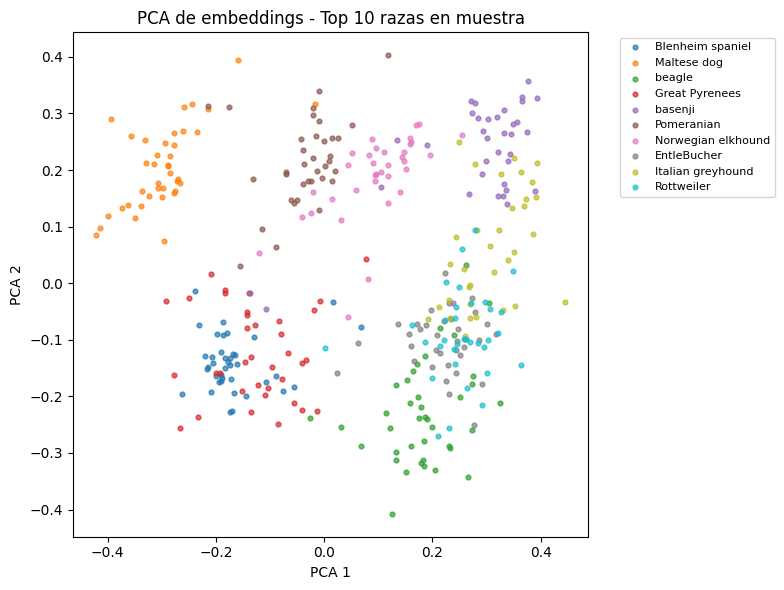

In [24]:
# 17. PCA para visualizar embeddings

PCA_SAMPLE_SIZE = 3000

if len(embeddings_l2) >= 2:
    sample_size = min(PCA_SAMPLE_SIZE, len(embeddings_l2))
    sample_idx = np.random.choice(len(embeddings_l2), size=sample_size, replace=False)

    sampled_embeddings = embeddings_l2[sample_idx]
    sampled_meta = embedding_input_df.iloc[sample_idx].reset_index(drop=True)

    pca = PCA(n_components=2, random_state=SEED)
    pca_xy = pca.fit_transform(sampled_embeddings)

    pca_df = pd.DataFrame({
        "pca_1": pca_xy[:, 0],
        "pca_2": pca_xy[:, 1],
        "breed": sampled_meta["breed"].values,
        "image_input_path": sampled_meta["image_input_path"].values
    })

    PCA_PATH = STEP03_REPORTS_PATH / f"step03_{INPUT_VARIANT}_pca_embeddings.csv"
    pca_df.to_csv(PCA_PATH, index=False)

    print("Varianza explicada PCA:", pca.explained_variance_ratio_)
    print("PCA guardado en:", PCA_PATH)

    # Para no saturar la gráfica con 120 razas, mostramos solo top 10 razas más frecuentes de la muestra.
    top_breeds = pca_df["breed"].value_counts().head(10).index
    plot_df = pca_df[pca_df["breed"].isin(top_breeds)].copy()

    plt.figure(figsize=(8, 6))
    for breed in top_breeds:
        subset = plot_df[plot_df["breed"] == breed]
        plt.scatter(subset["pca_1"], subset["pca_2"], s=12, alpha=0.7, label=breed)

    plt.title("PCA de embeddings - Top 10 razas en muestra")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(STEP03_PLOTS_PATH / f"step03_{INPUT_VARIANT}_pca_embeddings_top10_breeds.png", dpi=150)
    plt.show()

else:
    print("No hay suficientes embeddings para PCA.")

# Prueba rápida de similitud

Esta sección calcula vecinos visualmente similares usando similitud coseno.  
Será la base del paso 04, donde se compararán embeddings de imágenes de la misma raza.

In [ ]:
# 18. Vecinos más similares por embedding

def get_similar_images(query_index, embeddings_normalized, metadata_df, top_k=5):
    query_vector = embeddings_normalized[query_index].reshape(1, -1)
    sims = cosine_similarity(query_vector, embeddings_normalized)[0]

    # Excluir la misma imagen
    sims[query_index] = -1

    top_indices = np.argsort(sims)[::-1][:top_k]

    results = metadata_df.iloc[top_indices].copy()
    results["similarity"] = sims[top_indices]
    results["query_image"] = metadata_df.iloc[query_index]["image_input_path"]
    results["query_breed"] = metadata_df.iloc[query_index]["breed"]

    return results

if len(embeddings_l2) > 10:
    query_index = 0
    similar_df = get_similar_images(
        query_index=query_index,
        embeddings_normalized=embeddings_l2,
        metadata_df=embedding_input_df.reset_index(drop=True),
        top_k=10
    )

    SIMILARITY_EXAMPLE_PATH = STEP03_REPORTS_PATH / f"step03_{INPUT_VARIANT}_similarity_example.csv"
    similar_df.to_csv(SIMILARITY_EXAMPLE_PATH, index=False)

    print("Imagen consulta:")
    print(embedding_input_df.iloc[query_index]["image_input_path"])
    print("Raza consulta:", embedding_input_df.iloc[query_index]["breed"])
    display(similar_df[["image_input_path", "breed", "similarity", "query_breed"]])

else:
    print("No hay suficientes embeddings para calcular similitud.")

In [ ]:
# 19. Visualización de ejemplo de similitud

def show_image_grid(paths, titles=None, max_images=6):
    paths = list(paths)[:max_images]
    n = len(paths)

    if n == 0:
        print("No hay imágenes para mostrar.")
        return

    plt.figure(figsize=(3 * n, 3))

    for i, p in enumerate(paths):
        img = Image.open(p).convert("RGB")
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        if titles is not None:
            plt.title(titles[i], fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

if len(embeddings_l2) > 10:
    query_path = embedding_input_df.iloc[0]["image_input_path"]
    neighbor_paths = similar_df["image_input_path"].tolist()[:5]

    paths_to_show = [query_path] + neighbor_paths
    titles = ["Query"] + [f"Sim {i+1}" for i in range(len(neighbor_paths))]

    show_image_grid(paths_to_show, titles=titles, max_images=6)

# Análisis de métricas finales Paso 03: Features visuales y embeddings

En este paso se generaron dos tipos de representaciones visuales a partir de las imágenes válidas producidas en el Paso 02.

Primero, se extrajeron **características visuales interpretables** mediante OpenCV. Estas variables permiten describir condiciones visuales de cada imagen, como brillo, contraste, nitidez, saturación, color dominante y densidad de bordes.

Después, se extrajeron **embeddings profundos** utilizando el modelo EfficientNet entrenado en el Paso 02. Estos embeddings representan cada imagen como un vector numérico y serán utilizados en el Paso 04 para comparar similitud visual mediante similitud coseno.

## 1. Métricas de extracción de features visuales

Las features visuales permiten analizar la calidad y características generales de las imágenes procesadas.

| Indicador | Interpretación |
|---|---|
| `total_images_received_from_step02` | Total de imágenes válidas recibidas desde el Paso 02 |
| `visual_features_generated` | Imágenes para las que se calcularon features correctamente |
| `visual_feature_errors` | Imágenes que fallaron durante la extracción de features |
| `num_breeds` | Número de razas representadas en las features |
| `avg_brightness` | Brillo promedio de las imágenes |
| `avg_contrast` | Contraste promedio |
| `avg_sharpness` | Nitidez promedio medida con varianza del Laplaciano |
| `avg_edge_density` | Densidad promedio de bordes |
| `avg_colorfulness` | Nivel promedio de riqueza de color |

Estas métricas permiten verificar que las imágenes generadas después del Paso 02 no solo existen, sino que también tienen características visuales medibles y útiles para análisis posterior.

## 2. Interpretación de las features visuales

Las features extraídas cumplen una función interpretativa dentro del pipeline.

La métrica de **brillo promedio** ayuda a identificar imágenes oscuras o sobreexpuestas. El **contraste** permite evaluar la separación entre regiones claras y oscuras. La **nitidez**, calculada mediante la varianza del Laplaciano, permite detectar imágenes borrosas o con buena definición. La **densidad de bordes** indica qué tanta estructura visual existe en la imagen, lo cual es relevante para identificar contornos, orejas, hocico, cuerpo y textura del perro.

La métrica de **colorfulness** y la saturación ayudan a describir la riqueza de color de la imagen. Esto puede ser útil porque algunas razas tienen pelajes visualmente similares y otras pueden depender de diferencias de tono, textura o contraste.

En conjunto, estas features no sustituyen al modelo profundo, pero ayudan a explicar condiciones visuales que pueden afectar el desempeño del clasificador y la calidad de los embeddings.

## 3. Métricas de embeddings profundos

Los embeddings fueron generados a partir del modelo EfficientNet entrenado en el Paso 02. Para ello, se utilizó una capa intermedia del modelo en lugar de la capa final de clasificación.

| Indicador | Interpretación |
|---|---|
| `images_available_for_embedding` | Imágenes disponibles para generar embeddings |
| `embeddings_generated` | Embeddings generados correctamente |
| `embedding_errors` | Errores durante la extracción de embeddings |
| `embedding_dimension` | Tamaño del vector generado para cada imagen |
| `embedding_layer` | Capa del modelo usada como salida del embedding |
| `model_used` | Modelo entrenado del Paso 02 utilizado para extraer embeddings |
| `avg_embedding_norm` | Magnitud promedio de los vectores |
| `std_embedding_norm` | Variabilidad de las magnitudes |
| `num_breeds_with_embeddings` | Número de razas representadas en los embeddings |

Estas métricas permiten validar que la extracción de embeddings fue exitosa y que las imágenes quedaron representadas como vectores numéricos comparables.

## 4. Interpretación de los embeddings

A diferencia de la clasificación del Paso 02, donde el modelo produce una etiqueta de raza, en este paso el modelo genera una representación numérica de cada imagen.

Cada embedding resume información visual aprendida por EfficientNet, como forma general del perro, textura del pelaje, rasgos faciales, proporciones, postura, color y patrones visuales relevantes para diferenciar razas.

La ventaja de usar embeddings es que permiten comparar imágenes entre sí. Dos imágenes con embeddings cercanos deberían representar perros visualmente similares. Por eso, este paso es fundamental para el Paso 04, donde se utilizará similitud coseno para encontrar imágenes parecidas y analizar consistencia visual entre perros de la misma raza.

Además, los embeddings normalizados con L2 permiten que la comparación por coseno sea más estable, ya que la similitud se enfoca en la dirección de los vectores y no únicamente en su magnitud.

## 5. Métricas de estabilidad del proceso

El Paso 03 también permite evaluar la estabilidad técnica del pipeline.

Un resultado ideal en este paso es que:

- La cantidad de `visual_features_generated` sea igual o muy cercana a `total_images_received_from_step02`.
- La cantidad de `embeddings_generated` sea igual o muy cercana a `images_available_for_embedding`.
- `visual_feature_errors` y `embedding_errors` sean cero o muy bajos.
- Las 120 razas sigan representadas después de la extracción.
- La dimensión del embedding sea consistente para todas las imágenes.

Si estas condiciones se cumplen, significa que el Paso 03 no perdió información relevante y que las salidas están listas para el análisis de similitud del Paso 04.

## 6. Relación entre features visuales y embeddings

Este paso genera dos niveles de representación:

| Tipo de representación | Ventaja | Uso principal |
|---|---|---|
| Features visuales | Interpretables y fáciles de explicar | Analizar calidad, brillo, nitidez, color y bordes |
| Embeddings profundos | Capturan patrones complejos aprendidos por EfficientNet | Comparar imágenes y buscar similitud visual |

Las features visuales permiten explicar condiciones observables de la imagen. Los embeddings, en cambio, capturan relaciones más profundas que no siempre son interpretables directamente, pero que son útiles para comparación visual.

Por esta razón, ambas representaciones son complementarias. Las features ayudan a entender la calidad de entrada, mientras que los embeddings permiten construir un sistema de búsqueda y comparación visual.

## Conclusión final del Paso 03

El Paso 03 logró transformar las imágenes válidas del Paso 02 en representaciones visuales útiles para análisis posterior.

Primero, se generaron features visuales interpretables mediante OpenCV. Estas métricas permiten describir la calidad visual de cada imagen, incluyendo brillo, contraste, nitidez, color, saturación y densidad de bordes. Esto agrega una capa explicativa al pipeline, ya que permite analizar por qué algunas imágenes pueden ser más fáciles o difíciles para los modelos.

Después, se generaron embeddings profundos usando el modelo EfficientNet entrenado en el Paso 02. Estos embeddings convierten cada imagen en un vector numérico que resume patrones visuales aprendidos por el modelo. A diferencia de una etiqueta de raza, el embedding permite comparar imágenes entre sí y medir similitud visual.

La combinación de features interpretables y embeddings profundos fortalece el pipeline porque une análisis explicable con representación aprendida. Las features permiten entender la calidad visual de las imágenes, mientras que los embeddings preparan la información para el siguiente paso: comparación de imágenes mediante similitud coseno.

En conclusión, el Paso 03 conecta la clasificación supervisada del Paso 02 con el análisis de similitud del Paso 04. Gracias a este paso, el sistema no solo puede clasificar razas, sino también representar visualmente cada perro y compararlo contra otros perros de la base de datos.